1        G            97.3%     0.247       14      
2        F            97.6%     0.217       18      
3        T            82.7%     1.145       18      
4        F            96.0%     0.301       12      
5        S            85.7%     0.992       19      
6        S            66.4%     1.962       20      
7        Y            90.0%     0.714       19      
8        S            70.1%     1.702       20      

Средняя энтропия: 0.910
Максимальная энтропия: 1.962
Минимальная энтропия: 0.217
1        I            96.4%     0.307       15      
2        S            86.6%     0.913       19      
3        S            75.9%     1.553       20      
4        S            74.0%     1.600       20      
5        S            80.5%     1.103       20      
6        S            63.6%     2.080       20      
7        Y            82.4%     1.206       20      
8        I            86.1%     0.968       19      

Средняя энтропия: 1.216
Максимальная энтропия: 2.080
Минимальная энтр

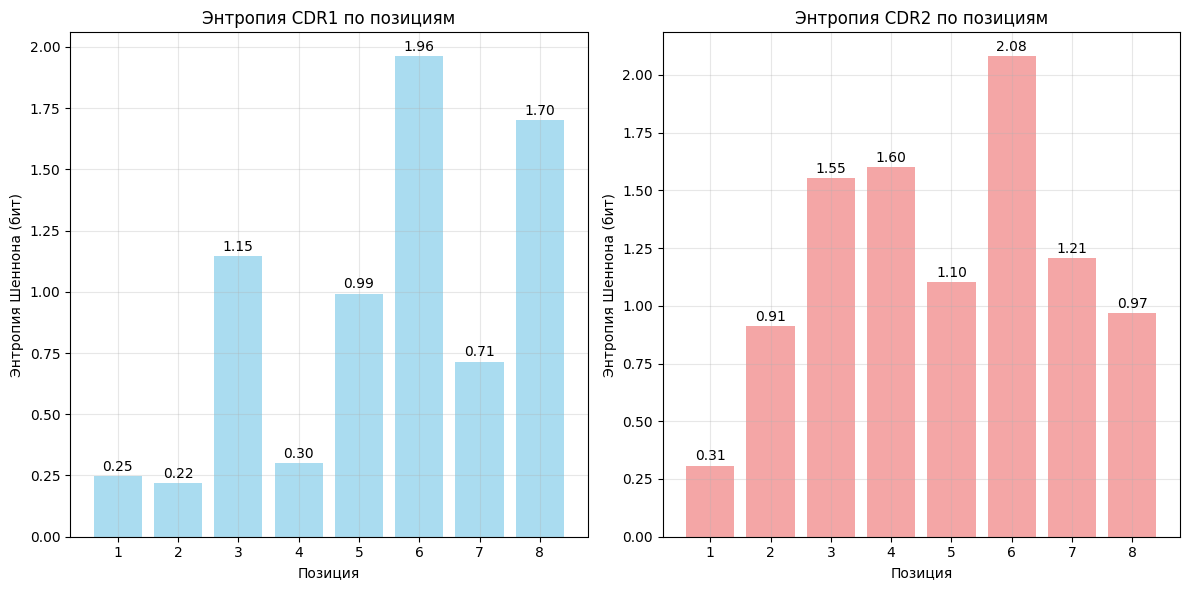

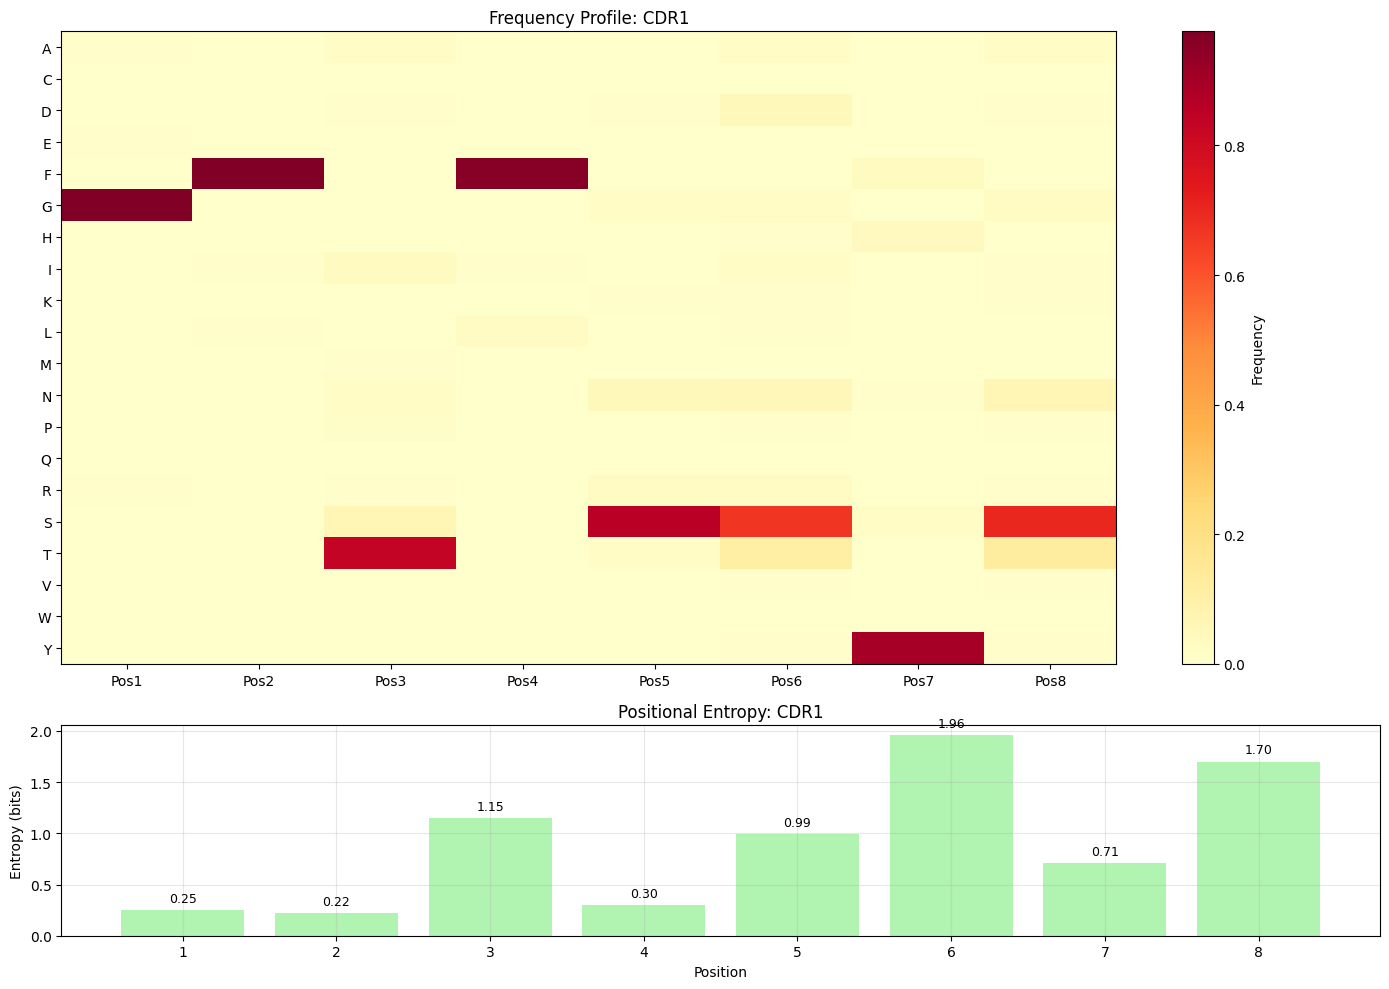

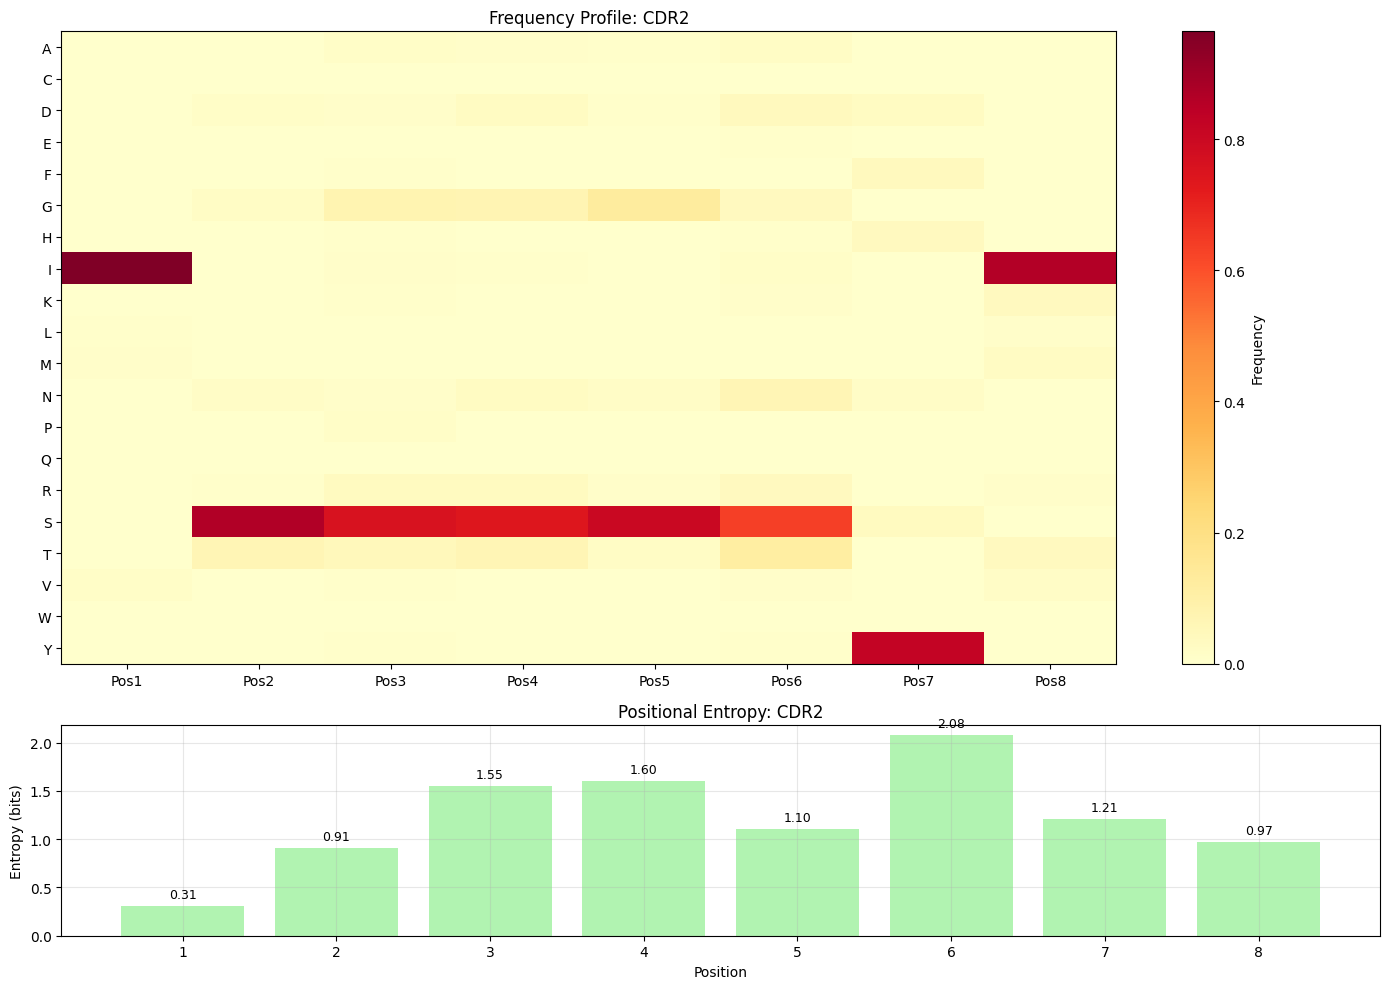

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import math

df = pd.read_csv('ighv3-21_cdr_both_length8.csv')

def calculate_entropy(frequencies):
    """Рассчитывает энтропию Шеннона для распределения частот"""
    entropy = 0
    for freq in frequencies.values():
        if freq > 0:
            entropy -= freq * math.log2(freq)
    return entropy

def calculate_frequency_profile_with_entropy(sequences, region_name):
    """Рассчитывает частотный профиль и энтропию для набора последовательностей"""
    if len(sequences) == 0:
        return None

    seq_length = len(sequences.iloc[0])

    frequency_matrix = []
    position_entropies = []

    for position in range(seq_length):
        aa_at_position = sequences.str[position]
        aa_counts = Counter(aa_at_position)
        total = sum(aa_counts.values())

        aa_frequencies = {aa: count/total for aa, count in aa_counts.items()}

        entropy = calculate_entropy(aa_frequencies)
        position_entropies.append(entropy)

        top_aa, top_freq = max(aa_frequencies.items(), key=lambda x: x[1])

        frequency_matrix.append({
            'position': position + 1,
            'frequencies': aa_frequencies,
            'total': total,
            'top_aa': top_aa,
            'top_freq': top_freq,
            'entropy': entropy,
            'unique_aa': len(aa_frequencies)
        })

        print(f"{position + 1:<8} {top_aa:<12} {top_freq:.1%}{'':<4} {entropy:.3f}{'':<6} {len(aa_frequencies):<8}")

    avg_entropy = np.mean(position_entropies)
    print(f"\nСредняя энтропия: {avg_entropy:.3f}")
    print(f"Максимальная энтропия: {max(position_entropies):.3f}")
    print(f"Минимальная энтропия: {min(position_entropies):.3f}")

    return frequency_matrix, position_entropies

cdr1_sequences = df['cdr1_aa_heavy'].dropna()
cdr1_profile, cdr1_entropies = calculate_frequency_profile_with_entropy(cdr1_sequences, "CDR1")

cdr2_sequences = df['cdr2_aa_heavy'].dropna()
cdr2_profile, cdr2_entropies = calculate_frequency_profile_with_entropy(cdr2_sequences, "CDR2")

def plot_entropy_profiles(cdr1_entropies, cdr2_entropies):
    """Строит график энтропии по позициям"""
    plt.figure(figsize=(12, 6))

    positions = range(1, len(cdr1_entropies) + 1)

    plt.subplot(1, 2, 1)
    plt.bar(positions, cdr1_entropies, color='skyblue', alpha=0.7)
    plt.title('Энтропия CDR1 по позициям')
    plt.xlabel('Позиция')
    plt.ylabel('Энтропия Шеннона (бит)')
    plt.xticks(positions)
    plt.grid(True, alpha=0.3)

    for i, v in enumerate(cdr1_entropies):
        plt.text(i + 1, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

    plt.subplot(1, 2, 2)
    plt.bar(positions, cdr2_entropies, color='lightcoral', alpha=0.7)
    plt.title('Энтропия CDR2 по позициям')
    plt.xlabel('Позиция')
    plt.ylabel('Энтропия Шеннона (бит)')
    plt.xticks(positions)
    plt.grid(True, alpha=0.3)

    for i, v in enumerate(cdr2_entropies):
        plt.text(i + 1, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('cdr_entropy_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

if cdr1_entropies and cdr2_entropies:
    plot_entropy_profiles(cdr1_entropies, cdr2_entropies)

def plot_frequency_profiles_with_entropy(profile, title, filename):
    """Строит тепловую карту частотных профилей с энтропией"""
    if not profile:
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                   gridspec_kw={'height_ratios': [3, 1]})

    all_aa = set()
    for pos_data in profile:
        all_aa.update(pos_data['frequencies'].keys())
    all_aa = sorted(all_aa)

    freq_matrix = np.zeros((len(all_aa), len(profile)))

    for i, pos_data in enumerate(profile):
        for j, aa in enumerate(all_aa):
            freq_matrix[j, i] = pos_data['frequencies'].get(aa, 0)

    im = ax1.imshow(freq_matrix, cmap='YlOrRd', aspect='auto')
    ax1.set_xticks(range(len(profile)))
    ax1.set_xticklabels([f'Pos{i+1}' for i in range(len(profile))])
    ax1.set_yticks(range(len(all_aa)))
    ax1.set_yticklabels(all_aa)
    ax1.set_title(f'Frequency Profile: {title}')
    plt.colorbar(im, ax=ax1, label='Frequency')

    entropies = [pos_data['entropy'] for pos_data in profile]
    positions = range(1, len(profile) + 1)

    bars = ax2.bar(positions, entropies, color='lightgreen', alpha=0.7)
    ax2.set_xlabel('Position')
    ax2.set_ylabel('Entropy (bits)')
    ax2.set_xticks(positions)
    ax2.set_title(f'Positional Entropy: {title}')
    ax2.grid(True, alpha=0.3)

    for bar, entropy in zip(bars, entropies):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{entropy:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'frequency_entropy_{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

if cdr1_profile:
    plot_frequency_profiles_with_entropy(cdr1_profile, 'CDR1', 'cdr1')

if cdr2_profile:
    plot_frequency_profiles_with_entropy(cdr2_profile, 'CDR2', 'cdr2')

def save_profile_with_entropy_to_csv(profile, filename):
    """Сохраняет частотный профиль с энтропией в CSV"""
    rows = []
    for pos_data in profile:
        for aa, freq in pos_data['frequencies'].items():
            rows.append({
                'position': pos_data['position'],
                'amino_acid': aa,
                'frequency': freq,
                'count': int(freq * pos_data['total']),
                'entropy': pos_data['entropy'],
                'is_top_aa': (aa == pos_data['top_aa'])
            })

    profile_df = pd.DataFrame(rows)
    profile_df.to_csv(filename, index=False)
    print(f"Профиль с энтропией сохранен: {filename}")